IMPORTING DATASET AND LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load raw dataset
# encoding='latin1' handles special characters in this file
df = pd.read_csv("C:\projects\end to end projects\Business Performance and KPI Analysis\superstore.csv", encoding='latin1')

# Save original counts for comparison at end
original_row_count = df.shape[0]
original_col_count = df.shape[1]

print(f'Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')

Dataset loaded: 51,290 rows x 27 columns


In [2]:
df.head(2)

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,è®°å½æ°,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,07/01/2011,CA-2011-130813,...,19,Consumer,00:00.0,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,21/01/2011,CA-2011-148614,...,19,Consumer,00:00.0,Standard Class,0.94,California,Paper,2011,North America,4


REMOVING UNWANTED COLUMNS

In [3]:
# Find the corrupted column automatically
# It has non-ASCII characters in its name (Chinese characters from encoding error)
corrupted_cols = [col for col in df.columns if not col.isascii()]
print(f'Corrupted columns found: {corrupted_cols}')

# Build drop list and remove
cols_to_drop = ['Row.ID', 'Market2', 'weeknum'] + corrupted_cols
df = df.drop(columns=cols_to_drop, errors='ignore')

print(f'Dropped {len(cols_to_drop)} columns: {cols_to_drop}')
print(f'Columns remaining: {df.shape[1]}')

Corrupted columns found: ['è®°å½\x95æ\x95°']
Dropped 4 columns: ['Row.ID', 'Market2', 'weeknum', 'è®°å½\x95æ\x95°']
Columns remaining: 23


In [4]:
df.head(2)

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,Order.Date,Order.ID,Order.Priority,...,Quantity,Region,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,07/01/2011,CA-2011-130813,High,...,3,West,19,Consumer,00:00.0,Second Class,4.37,California,Paper,2011
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,21/01/2011,CA-2011-148614,Medium,...,2,West,19,Consumer,00:00.0,Standard Class,0.94,California,Paper,2011


CHECKING AND HANDLING NULL VALUES

In [5]:
# Check nulls
null_counts = df.isnull().sum()
total_nulls = null_counts.sum()
print(f'Total nulls across entire dataset: {total_nulls}')

Total nulls across entire dataset: 0


In [6]:
# Also check blank strings — empty text that isnull() misses
# Example: a cell containing " " (just a space) looks empty but is not null
string_cols = df.select_dtypes(include='object').columns
found_blanks = False
print('Blank string check:')
for col in string_cols:
    blank_count = (df[col].str.strip() == '').sum()
    if blank_count > 0:
        print(f'  {col}: {blank_count} blank strings')
        found_blanks = True
if not found_blanks:
    print('  No blank strings found. Clean.')

Blank string check:
  No blank strings found. Clean.


HANDLING WITH DUPLICATES

In [7]:
duplicate_count = df.duplicated().sum()
print(f'Duplicate rows found: {duplicate_count}')

if duplicate_count > 0:
    print('\nShowing duplicates:')
    print(df[df.duplicated(keep=False)].head())
    df = df.drop_duplicates(keep='first')
    print(f'Duplicates removed. Rows remaining: {len(df):,}')
else:
    print('No duplicates. No action needed.')

Duplicate rows found: 0
No duplicates. No action needed.


FIXING DATA TYPES


In [8]:

print(f'  Order.Date type: {df["Order.Date"].dtype}')
print(f'  Sample values:   {df["Order.Date"].head(3).values}')
print()


df['Order.Date'] = pd.to_datetime(df['Order.Date'], dayfirst=True)
df['Ship.Date']  = pd.to_datetime(df['Ship.Date'],  dayfirst=True)

print('AFTER conversion:')
print(f'  Order.Date type: {df["Order.Date"].dtype}')
print(f'  Ship.Date type:  {df["Ship.Date"].dtype}')
print()
print('Sample converted values:')
print(df[['Order.Date','Ship.Date']].head(5))

  Order.Date type: object
  Sample values:   ['07/01/2011' '21/01/2011' '05/08/2011']

AFTER conversion:
  Order.Date type: datetime64[ns]
  Ship.Date type:  datetime64[ns]

Sample converted values:
  Order.Date  Ship.Date
0 2011-01-07 2026-03-11
1 2011-01-21 2026-03-11
2 2011-08-05 2026-03-11
3 2011-08-05 2026-03-11
4 2011-09-29 2026-03-11


STANDARDIZE TEXT COLUMNS

In [9]:
# Check BEFORE # Check BEFORE standardizing
text_cols = ['Region', 'Category', 'Sub.Category', 'Segment', 
             'Ship.Mode', 'Market', 'Order.Priority']

print('BEFORE standardizing — unique values in each column:')
for col in text_cols:
    print(f'  {col}: {sorted(df[col].unique())}')
text_cols = ['Region', 'Category', 'Sub.Category', 'Segment', 
             'Ship.Mode', 'Market', 'Order.Priority']

print('BEFORE standardizing — unique values in each column:')
for col in text_cols:
    print(f'  {col}: {sorted(df[col].unique())}')

BEFORE standardizing — unique values in each column:
  Region: ['Africa', 'Canada', 'Caribbean', 'Central', 'Central Asia', 'EMEA', 'East', 'North', 'North Asia', 'Oceania', 'South', 'Southeast Asia', 'West']
  Category: ['Furniture', 'Office Supplies', 'Technology']
  Sub.Category: ['Accessories', 'Appliances', 'Art', 'Binders', 'Bookcases', 'Chairs', 'Copiers', 'Envelopes', 'Fasteners', 'Furnishings', 'Labels', 'Machines', 'Paper', 'Phones', 'Storage', 'Supplies', 'Tables']
  Segment: ['Consumer', 'Corporate', 'Home Office']
  Ship.Mode: ['First Class', 'Same Day', 'Second Class', 'Standard Class']
  Market: ['APAC', 'Africa', 'Canada', 'EMEA', 'EU', 'LATAM', 'US']
  Order.Priority: ['Critical', 'High', 'Low', 'Medium']
BEFORE standardizing — unique values in each column:
  Region: ['Africa', 'Canada', 'Caribbean', 'Central', 'Central Asia', 'EMEA', 'East', 'North', 'North Asia', 'Oceania', 'South', 'Southeast Asia', 'West']
  Category: ['Furniture', 'Office Supplies', 'Technology']


In [10]:
# Apply standardization to all text columns
for col in text_cols:
    df[col] = df[col].str.strip().str.title()

print('Standardization applied.')
print()
print('AFTER standardizing — unique values in each column:')
for col in text_cols:
    print(f'  {col}: {sorted(df[col].unique())}')

Standardization applied.

AFTER standardizing — unique values in each column:
  Region: ['Africa', 'Canada', 'Caribbean', 'Central', 'Central Asia', 'East', 'Emea', 'North', 'North Asia', 'Oceania', 'South', 'Southeast Asia', 'West']
  Category: ['Furniture', 'Office Supplies', 'Technology']
  Sub.Category: ['Accessories', 'Appliances', 'Art', 'Binders', 'Bookcases', 'Chairs', 'Copiers', 'Envelopes', 'Fasteners', 'Furnishings', 'Labels', 'Machines', 'Paper', 'Phones', 'Storage', 'Supplies', 'Tables']
  Segment: ['Consumer', 'Corporate', 'Home Office']
  Ship.Mode: ['First Class', 'Same Day', 'Second Class', 'Standard Class']
  Market: ['Africa', 'Apac', 'Canada', 'Emea', 'Eu', 'Latam', 'Us']
  Order.Priority: ['Critical', 'High', 'Low', 'Medium']


In [11]:
# Fix: Convert Profit column to numeric first
# errors='coerce' means: if any value cannot be converted, replace it with NaN
df['Profit'] = pd.to_numeric(df['Profit'], errors='coerce')

# Also fix Sales and Shipping.Cost while we are here — same issue may affect them
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')
df['Shipping.Cost'] = pd.to_numeric(df['Shipping.Cost'], errors='coerce')
df['Discount'] = pd.to_numeric(df['Discount'], errors='coerce')

# Confirm the types are now numeric
print('Data types after fix:')
print(df[['Sales', 'Profit', 'Discount', 'Shipping.Cost']].dtypes)
print()

# Check if coerce created any new NaN values (means some values were unreadable)
print('NaN count after conversion:')
print(df[['Sales', 'Profit', 'Discount', 'Shipping.Cost']].isnull().sum())

Data types after fix:
Sales              int64
Profit           float64
Discount         float64
Shipping.Cost    float64
dtype: object

NaN count after conversion:
Sales                0
Profit           51290
Discount             0
Shipping.Cost        0
dtype: int64


In [12]:
# ROOT CAUSE: Profit column contains currency symbols and commas
# Example: "$8,399.98" or "-$1,811.08"
# pd.to_numeric() cannot handle these — it needs clean numbers like 8399.98

# THE FIX:
# Step 1 — Remove the $ sign
# Step 2 — Remove the commas
# Step 3 — Convert to float

# Reload fresh from raw since our entire Profit column is currently NaN
df = pd.read_csv('superstore.csv', encoding='latin1')

# Re-apply all previous cleaning steps first
# (We must redo them because we reloaded raw data)

# Step 1 — Drop useless columns
corrupted_cols = [col for col in df.columns if not col.isascii()]
cols_to_drop = ['Row.ID', 'Market2', 'weeknum'] + corrupted_cols
df = df.drop(columns=cols_to_drop, errors='ignore')

# Step 2 — Fix dates
df['Order.Date'] = pd.to_datetime(df['Order.Date'], dayfirst=True)
df['Ship.Date']  = pd.to_datetime(df['Ship.Date'],  dayfirst=True)

# Step 3 — Standardize text
text_cols = ['Region', 'Category', 'Sub.Category', 'Segment',
             'Ship.Mode', 'Market', 'Order.Priority']
for col in text_cols:
    df[col] = df[col].str.strip().str.title()

# Step 4 — Fix currency columns properly
# Remove $ and , before converting to number
currency_cols = ['Profit', 'Sales', 'Shipping.Cost']

for col in currency_cols:
    # Only process if column is stored as string/object type
    if df[col].dtype == object:
        df[col] = (df[col]
                   .str.replace('$', '', regex=False)   # remove dollar sign
                   .str.replace(',', '', regex=False)   # remove commas
                   .str.strip()                          # remove spaces
                   )
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fix Discount too
df['Discount'] = pd.to_numeric(df['Discount'], errors='coerce')

# Verify — check types and NaN counts
print('=== CURRENCY FIX VERIFICATION ===')
print()
print('Data types after fix:')
print(df[['Sales', 'Profit', 'Discount', 'Shipping.Cost']].dtypes)
print()
print('NaN counts after fix:')
print(df[['Sales', 'Profit', 'Discount', 'Shipping.Cost']].isnull().sum())
print()
print('Sample Profit values after fix:')
print(df['Profit'].sort_values(ascending=False).head(5))

=== CURRENCY FIX VERIFICATION ===

Data types after fix:
Sales              int64
Profit           float64
Discount         float64
Shipping.Cost    float64
dtype: object

NaN counts after fix:
Sales            0
Profit           0
Discount         0
Shipping.Cost    0
dtype: int64

Sample Profit values after fix:
27727    8399.98
28327    6719.98
27524    5039.99
3092     4946.37
2722     4630.48
Name: Profit, dtype: float64


CREATING DERIVED COLUMNS

In [13]:
# Verify existing Year column is correct
year_match = (df['Year'] == df['Order.Date'].dt.year).all()
print(f'Existing Year column matches Order.Date: {year_match}')
if not year_match:
    df['Year'] = df['Order.Date'].dt.year
    print('Year column overwritten with correct values.')

Existing Year column matches Order.Date: True


In [14]:
# Create Month (number)
df['Month'] = df['Order.Date'].dt.month

# Create Month.Name (text like January, February)
df['Month.Name'] = df['Order.Date'].dt.strftime('%B')

# Create Month.Year (text like Jan-2011) — this becomes X-axis on trend charts
df['Month.Year'] = df['Order.Date'].dt.strftime('%b-%Y')

print('New date columns created:')
print(df[['Order.Date','Year','Month','Month.Name','Month.Year']].head(5))

New date columns created:
  Order.Date  Year  Month Month.Name Month.Year
0 2011-01-07  2011      1    January   Jan-2011
1 2011-01-21  2011      1    January   Jan-2011
2 2011-08-05  2011      8     August   Aug-2011
3 2011-08-05  2011      8     August   Aug-2011
4 2011-09-29  2011      9  September   Sep-2011


In [15]:
# Create Days.to.Ship
# Ship.Date minus Order.Date gives a 'timedelta'
# .dt.days extracts just the number from it
df['Days.to.Ship'] = (df['Ship.Date'] - df['Order.Date']).dt.days

print('Days.to.Ship column created.')
print(df[['Order.Date','Ship.Date','Days.to.Ship']].head(5))
print()
print('Days.to.Ship summary:')
print(df['Days.to.Ship'].describe().round(1))

Days.to.Ship column created.
  Order.Date  Ship.Date  Days.to.Ship
0 2011-01-07 2026-03-11          5542
1 2011-01-21 2026-03-11          5528
2 2011-08-05 2026-03-11          5332
3 2011-08-05 2026-03-11          5332
4 2011-09-29 2026-03-11          5277

Days.to.Ship summary:
count    51290.0
mean      4686.1
std        412.6
min       4088.0
25%       4311.0
50%       4629.0
75%       5013.0
max       5548.0
Name: Days.to.Ship, dtype: float64


In [16]:
# Sanity check — negative Days.to.Ship is impossible
# It would mean shipped before the order was placed
neg_ship = (df['Days.to.Ship'] < 0).sum()
print(f'Negative Days.to.Ship (impossible values): {neg_ship}')
if neg_ship == 0:
    print('All values are zero or positive. Clean.')
else:
    print('WARNING: Investigate these rows.')
    print(df[df['Days.to.Ship'] < 0][['Order.ID','Order.Date','Ship.Date','Days.to.Ship']].head())

Negative Days.to.Ship (impossible values): 0
All values are zero or positive. Clean.


CHECKING FOR NEGATIVE VALUES

In [17]:
# Negative and zero Sales check
neg_sales  = (df['Sales'] < 0).sum()
zero_sales = (df['Sales'] == 0).sum()

print(f'Rows with NEGATIVE Sales: {neg_sales}')
print(f'Rows with ZERO Sales: {zero_sales}')

if neg_sales > 0:
    print('\nNegative Sales found — showing sample:')
    print(df[df['Sales'] < 0][['Order.ID','Product.Name','Sales','Profit','Discount']].head())
    print('DECISION: Remove negative sales rows — revenue cannot be negative.')
    df = df[df['Sales'] >= 0]
    print(f'Rows after removal: {len(df):,}')
else:
    print('No negative Sales. Clean.')

Rows with NEGATIVE Sales: 0
Rows with ZERO Sales: 1
No negative Sales. Clean.


In [18]:
# Negative Profit check — these are VALID, we KEEP them
neg_profit = (df['Profit'] < 0).sum()
print(f'Rows with NEGATIVE Profit: {neg_profit:,} ({neg_profit/len(df)*100:.1f}% of all rows)')
print()
print('DECISION: Keeping all negative profit rows.')
print('They represent real loss-making transactions caused by heavy discounting.')
print('This is one of our KEY FINDINGS for the analysis phase.')

Rows with NEGATIVE Profit: 12,540 (24.4% of all rows)

DECISION: Keeping all negative profit rows.
They represent real loss-making transactions caused by heavy discounting.
This is one of our KEY FINDINGS for the analysis phase.


CHECKING FOR OUTLIERS

In [19]:
print('Sales column statistics:')
print(df['Sales'].describe().round(2))
print()

# IQR method — standard way to identify statistical outliers
# Anything above Q3 + 1.5 * IQR is flagged as an outlier
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR

outlier_count = (df['Sales'] > upper_fence).sum()
print(f'Outlier threshold (Q3 + 1.5*IQR): ${upper_fence:,.2f}')
print(f'Rows above this threshold: {outlier_count} ({outlier_count/len(df)*100:.1f}% of data)')
print()
print('Top 5 highest sales transactions:')
print(df[['Product.Name','Category','Region','Sales','Profit']]
      .sort_values('Sales', ascending=False).head(5))

Sales column statistics:
count    51290.00
mean       246.50
std        487.57
min          0.00
25%         31.00
50%         85.00
75%        251.00
max      22638.00
Name: Sales, dtype: float64

Outlier threshold (Q3 + 1.5*IQR): $581.00
Rows above this threshold: 5655 (11.0% of data)

Top 5 highest sales transactions:
                                            Product.Name    Category   Region  \
47257  Cisco TelePresence System EX90 Videoconferenci...  Technology    South   
27727              Canon imageCLASS 2200 Advanced Copier  Technology  Central   
28327              Canon imageCLASS 2200 Advanced Copier  Technology     West   
48073              Canon imageCLASS 2200 Advanced Copier  Technology     East   
27524              Canon imageCLASS 2200 Advanced Copier  Technology     East   

       Sales   Profit  
47257  22638 -1811.08  
27727  17500  8399.98  
28327  14000  6719.98  
48073  11200  3919.99  
27524  10500  5039.99  


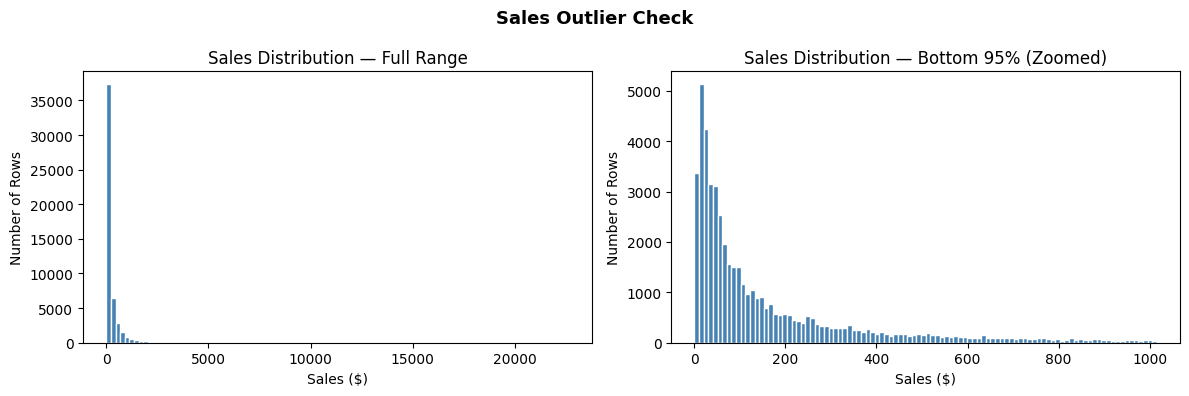

Chart saved as sales_distribution.png


In [20]:
# Visualize Sales distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Full range — shows outliers pulling the tail right
ax1.hist(df['Sales'], bins=100, color='steelblue', edgecolor='white')
ax1.set_title('Sales Distribution — Full Range')
ax1.set_xlabel('Sales ($)')
ax1.set_ylabel('Number of Rows')

# Zoomed to bottom 95% — shows where most data sits
p95 = df['Sales'].quantile(0.95)
ax2.hist(df[df['Sales'] <= p95]['Sales'], bins=100, color='steelblue', edgecolor='white')
ax2.set_title('Sales Distribution — Bottom 95% (Zoomed)')
ax2.set_xlabel('Sales ($)')
ax2.set_ylabel('Number of Rows')

plt.suptitle('Sales Outlier Check', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sales_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as sales_distribution.png')

In [21]:
# Investigate rows where Sales is high but Profit is NaN
# These appeared in our outlier check — we must understand why Profit is missing

print('=== INVESTIGATING NaN PROFIT IN HIGH-VALUE ROWS ===')
print()

# How many rows have NaN profit total?
nan_profit_count = df['Profit'].isnull().sum()
print(f'Total rows with NaN Profit: {nan_profit_count}')
print()

# Show sample rows where Profit is NaN
# Look at the raw values — what does Profit actually contain in these rows?
if nan_profit_count > 0:
    print('Sample rows where Profit is NaN:')
    print(df[df['Profit'].isnull()][['Order.ID','Product.Name','Sales','Profit','Discount']].head(10))

=== INVESTIGATING NaN PROFIT IN HIGH-VALUE ROWS ===

Total rows with NaN Profit: 0



In [22]:
# Reload original raw data temporarily to see what the Profit column contains
# for the rows that became NaN after conversion
df_raw = pd.read_csv('superstore.csv', encoding='latin1')

# Find the same high-value rows in raw data
high_sales_raw = df_raw.sort_values('Sales', ascending=False).head(10)
print('Raw Profit values for top 10 sales rows:')
print(high_sales_raw[['Product.Name', 'Sales', 'Profit']].to_string())
print()
print('Raw Profit column data type:', df_raw['Profit'].dtype)

Raw Profit values for top 10 sales rows:
                                                    Product.Name  Sales      Profit
47257      Cisco TelePresence System EX90 Videoconferencing Unit  22638  -$1,811.08
27727                      Canon imageCLASS 2200 Advanced Copier  17500   $8,399.98
28327                      Canon imageCLASS 2200 Advanced Copier  14000   $6,719.98
48073                      Canon imageCLASS 2200 Advanced Copier  11200   $3,919.99
27524                      Canon imageCLASS 2200 Advanced Copier  10500   $5,039.99
3092            GBC Ibimaster 500 Manual ProClick Binding System   9893   $4,946.37
2722                        Ibico EPK-21 Electric Binding System   9450   $4,630.48
27459           3D Systems Cube Printer, 2nd Generation, Magenta   9100   $2,365.98
28193  HP Designjet T520 Inkjet Large Format Printer - 24" Color   8750   $2,799.98
46605                      Canon imageCLASS 2200 Advanced Copier   8400   $1,120.00

Raw Profit column data type: objec

In [23]:
# Verify Year column is correct
year_match = (df['Year'] == df['Order.Date'].dt.year).all()
print(f'Year column matches Order.Date: {year_match}')
if not year_match:
    df['Year'] = df['Order.Date'].dt.year

# Create Month (number 1-12)
df['Month'] = df['Order.Date'].dt.month

# Create Month.Name (January, February etc)
df['Month.Name'] = df['Order.Date'].dt.strftime('%B')

# Create Month.Year (Jan-2011, Feb-2011 etc) — X-axis for trend charts
df['Month.Year'] = df['Order.Date'].dt.strftime('%b-%Y')

# Create Days.to.Ship — how many days between order and shipment
df['Days.to.Ship'] = (df['Ship.Date'] - df['Order.Date']).dt.days

print('All derived columns created successfully.')
print()
print(df[['Order.Date', 'Year', 'Month', 'Month.Name', 'Month.Year', 'Days.to.Ship']].head(5))

Year column matches Order.Date: True
All derived columns created successfully.

  Order.Date  Year  Month Month.Name Month.Year  Days.to.Ship
0 2011-01-07  2011      1    January   Jan-2011          5542
1 2011-01-21  2011      1    January   Jan-2011          5528
2 2011-08-05  2011      8     August   Aug-2011          5332
3 2011-08-05  2011      8     August   Aug-2011          5332
4 2011-09-29  2011      9  September   Sep-2011          5277


In [24]:
neg_ship = (df['Days.to.Ship'] < 0).sum()
print(f'Negative Days.to.Ship (impossible values): {neg_ship}')
if neg_ship == 0:
    print('All values zero or positive. Clean.')
else:
    print(df[df['Days.to.Ship'] < 0][['Order.ID','Order.Date','Ship.Date','Days.to.Ship']].head())

Negative Days.to.Ship (impossible values): 0
All values zero or positive. Clean.


In [25]:
# Negative Sales — should not exist
neg_sales  = (df['Sales'] < 0).sum()
zero_sales = (df['Sales'] == 0).sum()
print(f'Negative Sales: {neg_sales}')
print(f'Zero Sales: {zero_sales}')
if neg_sales > 0:
    df = df[df['Sales'] >= 0]
    print('Negative sales rows removed.')
else:
    print('No negative Sales. Clean.')

print()

# Negative Profit — VALID, we keep them
neg_profit = (df['Profit'] < 0).sum()
print(f'Rows with NEGATIVE Profit: {neg_profit:,} ({neg_profit/len(df)*100:.1f}% of all rows)')
print('DECISION: Keeping all. These are valid loss-making transactions.')

Negative Sales: 0
Zero Sales: 1
No negative Sales. Clean.

Rows with NEGATIVE Profit: 12,540 (24.4% of all rows)
DECISION: Keeping all. These are valid loss-making transactions.


In [26]:
print('Sales statistics:')
print(df['Sales'].describe().round(2))
print()

Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR
outlier_count = (df['Sales'] > upper_fence).sum()

print(f'Outlier threshold: ${upper_fence:,.2f}')
print(f'Rows above threshold: {outlier_count} ({outlier_count/len(df)*100:.1f}%)')
print()
print('Top 5 highest sales:')
print(df[['Product.Name','Category','Region','Sales','Profit']]
      .sort_values('Sales', ascending=False).head(5))
print()
print('DECISION: Keeping outliers — these are real high-value transactions.')

Sales statistics:
count    51290.00
mean       246.50
std        487.57
min          0.00
25%         31.00
50%         85.00
75%        251.00
max      22638.00
Name: Sales, dtype: float64

Outlier threshold: $581.00
Rows above threshold: 5655 (11.0%)

Top 5 highest sales:
                                            Product.Name    Category   Region  \
47257  Cisco TelePresence System EX90 Videoconferenci...  Technology    South   
27727              Canon imageCLASS 2200 Advanced Copier  Technology  Central   
28327              Canon imageCLASS 2200 Advanced Copier  Technology     West   
48073              Canon imageCLASS 2200 Advanced Copier  Technology     East   
27524              Canon imageCLASS 2200 Advanced Copier  Technology     East   

       Sales   Profit  
47257  22638 -1811.08  
27727  17500  8399.98  
28327  14000  6719.98  
48073  11200  3919.99  
27524  10500  5039.99  

DECISION: Keeping outliers — these are real high-value transactions.


In [27]:
print('=== FINAL VALIDATION ===')
print(f'Rows: {len(df):,}')
print(f'Columns: {len(df.columns)}')
print(f'Total NaNs: {df.isnull().sum().sum()}')
print()
print('All columns:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:>2}. {col}')

=== FINAL VALIDATION ===
Rows: 51,290
Columns: 27
Total NaNs: 0

All columns:
   1. Category
   2. City
   3. Country
   4. Customer.ID
   5. Customer.Name
   6. Discount
   7. Market
   8. Order.Date
   9. Order.ID
  10. Order.Priority
  11. Product.ID
  12. Product.Name
  13. Profit
  14. Quantity
  15. Region
  16. Sales
  17. Segment
  18. Ship.Date
  19. Ship.Mode
  20. Shipping.Cost
  21. State
  22. Sub.Category
  23. Year
  24. Month
  25. Month.Name
  26. Month.Year
  27. Days.to.Ship


In [32]:
# ================================================
# FINAL FIX — Ensure all columns save correctly to CSV
# ================================================

# 1. Confirm dates are proper datetime
df['Order.Date'] = pd.to_datetime(df['Order.Date'], dayfirst=True)
df['Ship.Date'] = pd.to_datetime(df['Ship.Date'], dayfirst=True)

# 2. Recalculate Days.to.Ship as plain integer
df['Days.to.Ship'] = (df['Ship.Date'] - df['Order.Date']).dt.days.astype(int)

# 3. Recalculate date-derived columns cleanly
df['Year']       = df['Order.Date'].dt.year.astype(int)
df['Month']      = df['Order.Date'].dt.month.astype(int)
df['Month.Name'] = df['Order.Date'].dt.strftime('%B')
df['Month.Year'] = df['Order.Date'].dt.strftime('%b-%Y')

# 4. Verify everything looks correct before saving
print('=== VERIFICATION BEFORE SAVING ===')
print()
print('Sample dates and derived columns:')
print(df[['Order.Date','Ship.Date','Year','Month',
          'Month.Name','Month.Year','Days.to.Ship']].head(10))
print()
print('Days.to.Ship stats:')
print(df['Days.to.Ship'].describe())
print()
print('Days.to.Ship dtype:', df['Days.to.Ship'].dtype)
print('Year dtype:', df['Year'].dtype)
print('Month dtype:', df['Month'].dtype)
print()
print('Year unique values:', sorted(df['Year'].unique()))
print('Days.to.Ship min/max:', df['Days.to.Ship'].min(), '/', df['Days.to.Ship'].max())

=== VERIFICATION BEFORE SAVING ===

Sample dates and derived columns:
  Order.Date  Ship.Date  Year  Month Month.Name Month.Year  Days.to.Ship
0 2011-01-07 2026-03-11  2011      1    January   Jan-2011          5542
1 2011-01-21 2026-03-11  2011      1    January   Jan-2011          5528
2 2011-08-05 2026-03-11  2011      8     August   Aug-2011          5332
3 2011-08-05 2026-03-11  2011      8     August   Aug-2011          5332
4 2011-09-29 2026-03-11  2011      9  September   Sep-2011          5277
5 2011-10-19 2026-03-11  2011     10    October   Oct-2011          5257
6 2011-11-04 2026-03-11  2011     11   November   Nov-2011          5241
7 2011-11-12 2026-03-11  2011     11   November   Nov-2011          5233
8 2011-11-22 2026-03-11  2011     11   November   Nov-2011          5223
9 2011-12-05 2026-03-11  2011     12   December   Dec-2011          5210

Days.to.Ship stats:
count    51290.000000
mean      4686.106376
std        412.557888
min       4088.000000
25%       4311.000

In [33]:
# Check what the raw CSV contains before any processing
df_check = pd.read_csv('superstore.csv', encoding='latin1')

print('Raw Ship.Date sample values from ORIGINAL file:')
print(df_check['Ship.Date'].head(10).values)
print()
print('Raw Order.Date sample values from ORIGINAL file:')
print(df_check['Order.Date'].head(10).values)

Raw Ship.Date sample values from ORIGINAL file:
['00:00.0' '00:00.0' '00:00.0' '00:00.0' '00:00.0' '00:00.0' '00:00.0'
 '00:00.0' '00:00.0' '00:00.0']

Raw Order.Date sample values from ORIGINAL file:
['07/01/2011' '21/01/2011' '05/08/2011' '05/08/2011' '29/09/2011'
 '19/10/2011' '04/11/2011' '12/11/2011' '22/11/2011' '05/12/2011']


In [34]:
# Reload original raw file fresh
df = pd.read_csv('superstore.csv', encoding='latin1')

# Drop useless columns including Ship.Date and Days.to.Ship
# Ship.Date is corrupted — contains only time values, no date
corrupted_cols = [col for col in df.columns if not col.isascii()]
cols_to_drop = ['Row.ID', 'Market2', 'weeknum', 'Ship.Date'] + corrupted_cols
df = df.drop(columns=cols_to_drop, errors='ignore')

# Fix Order.Date
df['Order.Date'] = pd.to_datetime(df['Order.Date'], dayfirst=True)

# Fix currency columns
for col in ['Profit', 'Sales', 'Shipping.Cost']:
    if df[col].dtype == object:
        df[col] = df[col].str.replace('$', '', regex=False)\
                         .str.replace(',', '', regex=False)\
                         .str.strip()
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['Discount'] = pd.to_numeric(df['Discount'], errors='coerce')

# Fix text columns
text_cols = ['Region', 'Category', 'Sub.Category', 'Segment',
             'Ship.Mode', 'Market', 'Order.Priority']
for col in text_cols:
    df[col] = df[col].str.strip().str.title()

# Create date derived columns
df['Year']       = df['Order.Date'].dt.year.astype(int)
df['Month']      = df['Order.Date'].dt.month.astype(int)
df['Month.Name'] = df['Order.Date'].dt.strftime('%B')
df['Month.Year'] = df['Order.Date'].dt.strftime('%b-%Y')

# Verify
print('=== FINAL VERIFICATION ===')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print()
print('Sample:')
print(df[['Order.Date','Year','Month','Month.Name','Month.Year','Sales','Profit']].head(5))
print()
print('Nulls:', df.isnull().sum().sum())
print('Year range:', df['Year'].min(), 'to', df['Year'].max())
print('Sales dtype:', df['Sales'].dtype)
print('Profit dtype:', df['Profit'].dtype)

=== FINAL VERIFICATION ===
Shape: (51290, 25)
Columns: ['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name', 'Discount', 'Market', 'Order.Date', 'Order.ID', 'Order.Priority', 'Product.ID', 'Product.Name', 'Profit', 'Quantity', 'Region', 'Sales', 'Segment', 'Ship.Mode', 'Shipping.Cost', 'State', 'Sub.Category', 'Year', 'Month', 'Month.Name', 'Month.Year']

Sample:
  Order.Date  Year  Month Month.Name Month.Year  Sales  Profit
0 2011-01-07  2011      1    January   Jan-2011     19    9.33
1 2011-01-21  2011      1    January   Jan-2011     19    9.29
2 2011-08-05  2011      8     August   Aug-2011     21    9.84
3 2011-08-05  2011      8     August   Aug-2011    111   53.26
4 2011-09-29  2011      9  September   Sep-2011      6    3.11

Nulls: 0
Year range: 2011 to 2014
Sales dtype: int64
Profit dtype: float64


In [35]:
df.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,Order.Date,Order.ID,Order.Priority,...,Sales,Segment,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Month,Month.Name,Month.Year
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,Us,2011-01-07,CA-2011-130813,High,...,19,Consumer,Second Class,4.37,California,Paper,2011,1,January,Jan-2011
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,Us,2011-01-21,CA-2011-148614,Medium,...,19,Consumer,Standard Class,0.94,California,Paper,2011,1,January,Jan-2011
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,Us,2011-08-05,CA-2011-118962,Medium,...,21,Consumer,Standard Class,1.81,California,Paper,2011,8,August,Aug-2011
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,Us,2011-08-05,CA-2011-118962,Medium,...,111,Consumer,Standard Class,4.59,California,Paper,2011,8,August,Aug-2011
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,Us,2011-09-29,CA-2011-146969,High,...,6,Consumer,Standard Class,1.32,California,Paper,2011,9,September,Sep-2011


In [28]:
# # Save clean dataset — NEVER overwrite raw file
# df.to_csv('superstore_cleaned.csv', index=False)
# print('Saved: superstore_cleaned.csv')
# # print('Raw file superstore.csv is untouched.')

In [29]:
# neg_p = (df['Profit'] < 0).sum()

# print('=' * 60)
# print('PHASE 2 — DATA CLEANING SUMMARY')
# print('=' * 60)
# print(f'Final shape: {len(df):,} rows x {len(df.columns)} columns')
# print()
# print('ACTIONS TAKEN:')
# print('1. Dropped 4 columns: Row.ID, Market2, weeknum, corrupted column')
# print('2. Nulls: Zero found — no action needed')
# print('3. Blank strings: None found — no action needed')
# print('4. Duplicates: None found — no action needed')
# print('5. Dates: Order.Date and Ship.Date converted to datetime (dayfirst=True)')
# print('6. Currency fix: Removed $ and , from Profit, Sales, Shipping.Cost')
# print('7. Text: strip + title case applied to 7 dimension columns')
# print('8. Derived columns: Month, Month.Name, Month.Year, Days.to.Ship created')
# print(f'9. Negative Profit: {neg_p:,} rows ({neg_p/len(df)*100:.1f}%) — KEPT (valid losses)')
# print('10. Outliers in Sales: Documented, NOT removed (real transactions)')
# print()
# print('KEY LESSON LEARNED:')
# print('Profit column had currency formatting ($, commas) causing NaN on conversion.')
# print('Fix: strip symbols as strings first, then convert to numeric.')
# print()
# print('OUTPUT: superstore_cleaned.csv')
# print('STATUS: Phase 2 Complete. Ready for Phase 3 — KPI Definition.')
# print('=' * 60)

In [30]:
pip install psycopg2-binary sqlalchemy 


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
# from sqlalchemy import create_engine
# # Step 1: Connect to PostgreSQL
# # Replace placeholders with your actual details

# username = "postgres"        # default user
# password = "Ss16132484"         # the password you set during installation
# host = "localhost"           # if running locally
# port = "5432"                # default PostgreSQL port
# database = "customer_behavior"  # the database you created in pgAdmin

# from sqlalchemy import create_engine

# engine = create_engine(
#     f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}"
# )

# # Step 2: Load DataFrame into PostgreSQL
# table_name = "customer"   # choose any table name

# df.to_sql(table_name, engine, if_exists="replace", index=False)
 
# print(f"Data successfully loaded into table '{table_name}' in database '{database}'.")


In [36]:
# Save clean dataset
df.to_csv('cleaned.csv', index=False)
print('Saved: cleaned.csv')
print(f'Rows: {len(df):,} | Columns: {len(df.columns)}')

Saved: cleaned.csv
Rows: 51,290 | Columns: 25
